# Menjelaskan Model Forecasting PM2.5 dengan SHAP

Notebook ini digunakan untuk membuat tahap **explainability** pada model forecasting PM2.5 Jakarta. Model yang dijelaskan adalah **LightGBM terbaik** yang sebelumnya sudah diperoleh dari tahap tuning dan ablation study.

Fokus utama notebook ini adalah memahami **fitur apa saja yang paling memengaruhi prediksi PM2.5** pada tiga horizon:

| Horizon | Target Prediksi |
|---:|---|
| H6 | PM2.5 6 jam ke depan |
| H12 | PM2.5 12 jam ke depan |
| H24 | PM2.5 24 jam ke depan |

Notebook ini menggunakan dataset hasil ablation:

```text
outputs_ablation_datasets/dataset_h6_ablation.csv
outputs_ablation_datasets/dataset_h12_ablation.csv
outputs_ablation_datasets/dataset_h24_ablation.csv
```

Dataset hasil ablation digunakan karena fitur yang masuk ke model sudah lebih ringkas dan telah melewati proses seleksi berdasarkan performa. Dengan begitu, interpretasi SHAP menjadi lebih fokus pada fitur-fitur yang memang dipertahankan setelah eksperimen ablation.

Secara umum, notebook ini menjawab pertanyaan:

> Fitur apa yang paling berkontribusi terhadap prediksi PM2.5 pada horizon 6 jam, 12 jam, dan 24 jam?

## Dari Model Prediksi ke Interpretasi Fitur

Alur kerja notebook ini terdiri dari dua bagian besar, yaitu **SHAP global importance** dan **reasoning JSON**.

Alur prosesnya dapat diringkas sebagai berikut:

```text
Dataset hasil ablation
        ↓
Load best params LightGBM dari outputs_phase2/
        ↓
Latih ulang LightGBM per horizon
        ↓
Ambil sampel data untuk perhitungan SHAP
        ↓
Hitung SHAP values dengan TreeExplainer
        ↓
Simpan SHAP global importance dan grafik
        ↓
Bangun JSON sample-level untuk reasoning LLM
```

Bagian pertama menghasilkan interpretasi global. Interpretasi global menjelaskan fitur mana yang paling penting secara umum bagi model.

Bagian kedua menghasilkan interpretasi sample-level. Interpretasi sample-level menjelaskan alasan prediksi untuk beberapa contoh data tertentu, terutama contoh dengan error besar dan beberapa sample acak dari validation fold terakhir.

Dengan demikian, notebook ini menjadi jembatan antara:

| Tahap | Fungsi |
|---|---|
| Forecasting model | Menghasilkan prediksi angka PM2.5 |
| SHAP explainability | Menjelaskan kontribusi fitur terhadap prediksi |
| Reasoning JSON | Menyiapkan input terstruktur untuk analisis berbasis LLM |

## Output SHAP Global Importance

Notebook ini menghasilkan ringkasan dan visualisasi SHAP global importance untuk tiga horizon prediksi.

Output global SHAP yang dihasilkan adalah:

```text
outputs_shap_ablation/shap_importance_h6.csv
outputs_shap_ablation/shap_importance_h12.csv
outputs_shap_ablation/shap_importance_h24.csv
outputs_shap_ablation/shap_global_h6.png
outputs_shap_ablation/shap_global_h12.png
outputs_shap_ablation/shap_global_h24.png
outputs_shap_ablation/shap_top10_bar_h6.png
outputs_shap_ablation/shap_top10_bar_h12.png
outputs_shap_ablation/shap_top10_bar_h24.png
outputs_shap_ablation/shap_summary_info.csv
```

Selain itu, notebook juga menyimpan grafik gabungan tiga horizon dalam working directory:

```text
shap_global.png
```

Catatan penting: nama file output aktual pada kode **tidak memakai akhiran `_ablation`** pada nama file grafik dan CSV SHAP. Akhiran ablation hanya muncul pada nama folder `outputs_shap_ablation/`.

Interpretasi global importance dihitung menggunakan:

```text
mean absolute SHAP value
```

Artinya, semakin besar nilai `mean_abs_shap`, semakin besar kontribusi rata-rata fitur tersebut terhadap prediksi model. Nilai ini tidak menunjukkan arah kenaikan atau penurunan prediksi, tetapi menunjukkan seberapa kuat pengaruh fitur secara global.

## Output JSON untuk Reasoning Berbasis LLM

Selain visualisasi SHAP global, notebook ini juga menghasilkan file JSON yang dirancang untuk kebutuhan reasoning berbasis LLM.

Output JSON yang dihasilkan adalah:

```text
outputs_shap_ablation/reasoning_h6.json
outputs_shap_ablation/reasoning_h12.json
outputs_shap_ablation/reasoning_h24.json
outputs_shap_ablation/reasoning_all_horizons.json
```

Untuk setiap horizon, notebook memilih 10 sample dari validation fold terakhir:

| Jenis Sample | Jumlah | Tujuan |
|---|---:|---|
| Sample dengan absolute error terbesar | 5 | Melihat kasus yang paling sulit diprediksi |
| Sample acak dari sisa validation | 5 | Memberi contoh yang lebih beragam |

Setiap sample JSON berisi beberapa komponen utama:

| Komponen | Isi |
|---|---|
| Metadata sample | `sample_id`, `datetime`, `target_datetime`, `station_slug`, `station_id` |
| Informasi prediksi | `current_pm25`, `actual_target`, `prediction`, `absolute_error` |
| Context features | Fitur ringkas seperti waktu, cuaca, PM2.5 saat ini, lag, dan rolling |
| Top absolute contributors | Fitur dengan pengaruh SHAP terbesar tanpa melihat arah |
| Top positive contributors | Fitur yang mendorong prediksi naik |
| Top negative contributors | Fitur yang mendorong prediksi turun |

Output JSON ini membuat hasil prediksi lebih mudah dipakai untuk tahap berikutnya, misalnya membuat narasi penjelasan otomatis, analisis error, atau rekomendasi berbasis kondisi kualitas udara.

## Peran Notebook dalam Pipeline Forecasting

Notebook ini berada pada tahap **XAI dan reasoning preparation** dalam pipeline forecasting PM2.5.

Tahap sebelumnya sudah menghasilkan:

1. Dataset hasil ablation.
2. Best params LightGBM.
3. Model comparison.
4. Hasil ablation study.

Notebook ini melanjutkan pipeline dengan menjawab dua kebutuhan penting:

| Kebutuhan | Output |
|---|---|
| Menjelaskan fitur penting secara global | SHAP importance CSV dan grafik |
| Menyiapkan contoh penjelasan per sample | JSON reasoning per horizon |

Dengan notebook ini, pipeline tidak hanya menghasilkan prediksi numerik, tetapi juga mulai menyediakan dasar untuk menjelaskan **mengapa prediksi tertentu muncul**.

Secara praktis, hasil notebook ini dapat digunakan untuk:

1. Menulis interpretasi model dalam laporan.
2. Menjelaskan fitur yang paling dominan pada setiap horizon.
3. Membandingkan fitur penting H6, H12, dan H24.
4. Menganalisis kasus dengan error tinggi.
5. Menyusun input terstruktur untuk LLM reasoning atau recommendation generation.

Dengan demikian, notebook ini menjadi tahap transisi dari **forecasting model** menuju **explainable forecasting system**.

## Menyiapkan Konfigurasi SHAP dan Dataset Ablation

Cell ini menyiapkan library, path dataset, folder output, dan fungsi bantu untuk menjalankan SHAP explainability.

Library yang digunakan adalah:

| Library | Fungsi |
|---|---|
| `json` | Membaca best params dan menyimpan output reasoning |
| `pathlib.Path` | Mengatur path folder input-output |
| `numpy` | Operasi numerik |
| `pandas` | Membaca dan mengolah dataset |
| `matplotlib.pyplot` | Membuat grafik |
| `shap` | Menghitung SHAP values |
| `LGBMRegressor` | Model LightGBM yang akan dijelaskan |

Konfigurasi utama pada cell ini adalah:

| Konfigurasi | Nilai | Fungsi |
|---|---:|---|
| `SEED` | 42 | Menjaga reproducibility |
| `SHAP_SAMPLE_SIZE` | 3000 | Jumlah sample maksimum untuk perhitungan SHAP global |
| `PHASE2_DIR` | `outputs_phase2/` | Folder best params LightGBM |
| `OUT_DIR` | `outputs_shap_ablation/` | Folder output SHAP |

Dataset yang digunakan adalah dataset hasil ablation:

| Horizon | Dataset |
|---:|---|
| H6 | `outputs_ablation_datasets/dataset_h6_ablation.csv` |
| H12 | `outputs_ablation_datasets/dataset_h12_ablation.csv` |
| H24 | `outputs_ablation_datasets/dataset_h24_ablation.csv` |

### Fungsi `load_dataset()`

Fungsi ini membaca dataset CSV, mengubah kolom `datetime` dan `date` menjadi format datetime, lalu mengurutkan data berdasarkan `datetime` dan `station_slug`.

Pengurutan ini penting karena data merupakan time series multi-stasiun.

### Fungsi `load_best_lgb_params()`

Fungsi ini membaca best params LightGBM dari folder:

```text
outputs_phase2/
```

File yang dibaca mengikuti format:

```text
best_params_h6.json
best_params_h12.json
best_params_h24.json
```

Jika file best params tidak ditemukan, kode akan mengeluarkan error. Hal ini penting karena notebook SHAP ini memang bergantung pada hasil tuning sebelumnya.

### Fungsi `prepare_xy_onehot()`

Fungsi ini memisahkan fitur `X` dan target `y`, lalu melakukan one-hot encoding pada kolom kategorikal.

Beberapa kolom dikeluarkan dari fitur:

| Kolom | Alasan Dikeluarkan |
|---|---|
| Target horizon | Label yang harus diprediksi |
| `datetime` | Kolom waktu mentah |
| `date` | Kolom tanggal mentah |
| `station_name` | Redundan dengan identitas stasiun lain |
| `lokasi` | Kolom teks lokasi |
| `season_simple` | Kolom string musim |
| `pm25_raw` | Backup PM2.5 asli sebelum imputasi |
| `pm25_clean_full` | Duplikasi PM2.5 final jika tersedia |

Kolom object atau category yang masih tersisa diubah menjadi one-hot agar bisa diproses oleh LightGBM dan SHAP.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from lightgbm import LGBMRegressor

SEED = 42
SHAP_SAMPLE_SIZE = 3000   # bisa kecilkan kalau RAM berat

DATASET_PATHS = {
    6: "outputs_ablation_datasets/dataset_h6_ablation.csv",
    12: "outputs_ablation_datasets/dataset_h12_ablation.csv",
    24: "outputs_ablation_datasets/dataset_h24_ablation.csv",
}

PHASE2_DIR = Path("outputs_phase2")
OUT_DIR = Path("outputs_shap_ablation")
OUT_DIR.mkdir(exist_ok=True)


def load_dataset(path):
    df = pd.read_csv(path)
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.sort_values([c for c in ["datetime", "station_slug"] if c in df.columns]).reset_index(drop=True)
    return df


def load_best_lgb_params(horizon):
    fp = PHASE2_DIR / f"best_params_h{horizon}.json"
    if not fp.exists():
        raise FileNotFoundError(f"Best params file tidak ditemukan: {fp}")

    with open(fp, "r") as f:
        obj = json.load(f)

    return obj.get("best_params", {})


def prepare_xy_onehot(df, target_col):
    exclude_cols = {
        target_col,
        "datetime",
        "date",
        "station_name",
        "lokasi",
        "season_simple",
        "pm25_raw",
        "pm25_clean_full",
    }
    exclude_cols = {c for c in exclude_cols if c in df.columns}

    X = df[[c for c in df.columns if c not in exclude_cols]].copy()
    y = df[target_col].copy()

    obj_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    X = pd.get_dummies(X, columns=obj_cols, dummy_na=False)

    return X, y

## Menghitung SHAP Global Importance untuk H6, H12, dan H24

Cell ini menghitung SHAP global importance untuk tiga horizon prediksi.

Untuk setiap horizon, alur prosesnya adalah:

1. Membaca dataset hasil ablation.
2. Menentukan target horizon.
3. Membaca best params LightGBM.
4. Menyiapkan fitur dan target menggunakan one-hot encoding.
5. Melatih ulang `LGBMRegressor`.
6. Mengambil maksimum 3000 sample untuk perhitungan SHAP.
7. Menghitung SHAP values menggunakan `shap.TreeExplainer`.
8. Menghitung `mean_abs_shap` untuk setiap fitur.
9. Menyimpan hasil importance ke CSV.
10. Menyimpan summary plot SHAP per horizon.

### Mengapa Menggunakan Sample 3000 Baris?

Perhitungan SHAP bisa cukup berat, terutama jika jumlah baris dan fitur banyak. Karena itu, notebook menggunakan:

```text
SHAP_SAMPLE_SIZE = 3000
```

Jika jumlah data lebih besar dari 3000 baris, hanya 3000 baris yang dipilih secara acak dengan seed tetap. Ini membuat proses lebih ringan tetapi tetap memberi gambaran global yang representatif.

### Output yang Dihasilkan

| Horizon | CSV Importance | Summary Plot |
|---:|---|---|
| H6 | `outputs_shap_ablation/shap_importance_h6.csv` | `outputs_shap_ablation/shap_global_h6.png` |
| H12 | `outputs_shap_ablation/shap_importance_h12.csv` | `outputs_shap_ablation/shap_global_h12.png` |
| H24 | `outputs_shap_ablation/shap_importance_h24.csv` | `outputs_shap_ablation/shap_global_h24.png` |

### Top 10 Fitur H6

| Rank | Fitur | Mean Absolute SHAP |
|---:|---|---:|
| 1 | `pm25` | 14.338470 |
| 2 | `pm25_lag_1` | 2.161796 |
| 3 | `pm25_diff_1` | 1.137442 |
| 4 | `pm25_lag_24` | 0.583596 |
| 5 | `pm25_lag_6` | 0.538181 |
| 6 | `pm25_roll_max_3` | 0.521051 |
| 7 | `pm25_roll_min_6` | 0.279802 |
| 8 | `station_month_mean_pm25` | 0.262475 |
| 9 | `pm25_roll_mean_3` | 0.241766 |
| 10 | `wind_v` | 0.224382 |

Pada horizon 6 jam, fitur paling penting adalah `pm25`, diikuti oleh lag PM2.5 jangka pendek dan fitur perubahan PM2.5. Ini menunjukkan bahwa prediksi jangka pendek sangat bergantung pada kondisi PM2.5 terbaru.

### Top 10 Fitur H12

| Rank | Fitur | Mean Absolute SHAP |
|---:|---|---:|
| 1 | `pm25` | 14.039739 |
| 2 | `pm25_diff_1` | 1.504452 |
| 3 | `pm25_lag_24` | 0.965793 |
| 4 | `station_month_mean_pm25` | 0.635563 |
| 5 | `pm25_lag_48` | 0.569052 |
| 6 | `rain_roll_sum_12` | 0.425861 |
| 7 | `wind_v` | 0.416661 |
| 8 | `wind_speed_10m_roll_mean_12` | 0.289327 |
| 9 | `pm25_roll_std_12` | 0.281705 |
| 10 | `pm25_roll_min_12` | 0.231522 |

Pada horizon 12 jam, `pm25` tetap menjadi fitur paling dominan. Namun, fitur seperti `pm25_lag_24`, `pm25_lag_48`, dan fitur cuaca rolling mulai muncul lebih kuat, karena prediksi setengah hari ke depan membutuhkan konteks temporal yang lebih panjang.

### Top 10 Fitur H24

| Rank | Fitur | Mean Absolute SHAP |
|---:|---|---:|
| 1 | `pm25` | 8.316684 |
| 2 | `pm25_roll_mean_48` | 1.699833 |
| 3 | `station_month_mean_pm25` | 1.315983 |
| 4 | `pm25_lag_1` | 1.247233 |
| 5 | `pm25_lag_72` | 1.033341 |
| 6 | `wind_v` | 0.825483 |
| 7 | `pm25_roll_min_48` | 0.518690 |
| 8 | `pm25_roll_max_6` | 0.494154 |
| 9 | `pm25_lag_24` | 0.428963 |
| 10 | `pm25_roll_max_24` | 0.284143 |

Pada horizon 24 jam, kontribusi `pm25` masih paling besar, tetapi pengaruh fitur rolling dan lag panjang semakin terlihat. Ini sesuai dengan karakter prediksi satu hari ke depan yang lebih membutuhkan pola historis panjang dibanding hanya kondisi PM2.5 saat ini.


===== SHAP GLOBAL H6 =====


/tmp/ipykernel_276811/413772418.py:25: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Top 10 features:


,feature,mean_abs_shap
1,pm25,14.338470
44,pm25_lag_1,2.161796
50,pm25_diff_1,1.137442
49,pm25_lag_24,0.583596
47,pm25_lag_6,0.538181
55,pm25_roll_max_3,0.521051
58,pm25_roll_min_6,0.279802
129,station_month_mean_pm25,0.262475
52,pm25_roll_mean_3,0.241766
42,wind_v,0.224382


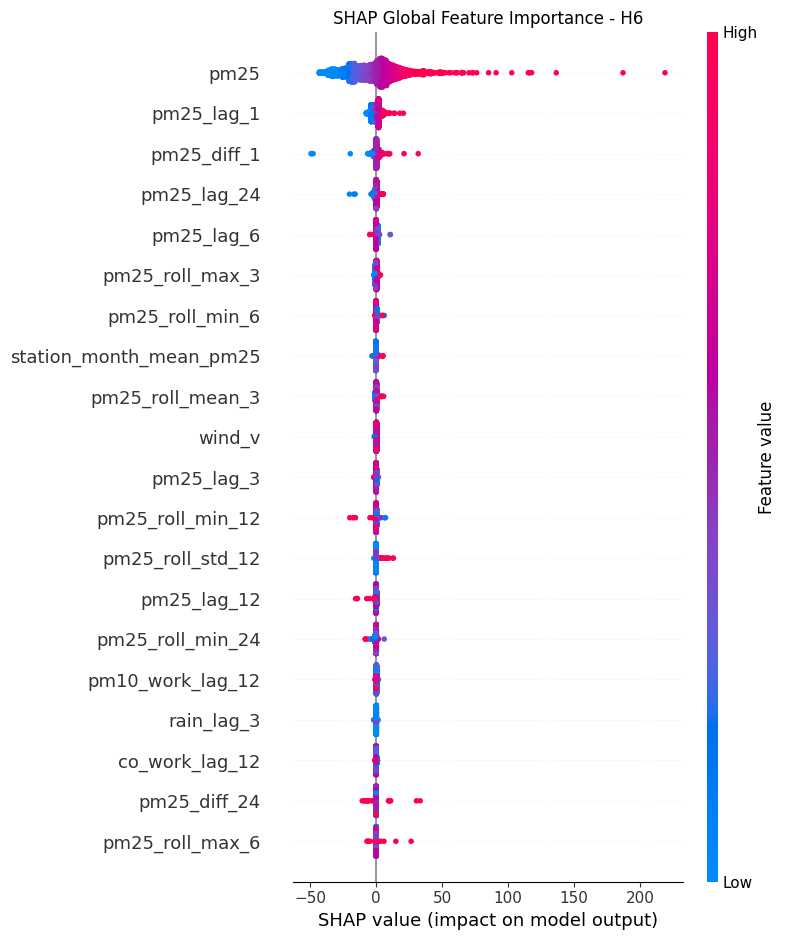


===== SHAP GLOBAL H12 =====


/tmp/ipykernel_276811/413772418.py:25: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Top 10 features:


,feature,mean_abs_shap
0,pm25,14.032630
50,pm25_diff_1,1.506529
48,pm25_lag_24,0.969830
145,station_month_mean_pm25,0.635558
49,pm25_lag_48,0.545387
41,wind_v,0.419762
111,rain_roll_sum_12,0.412217
61,pm25_roll_std_12,0.292054
114,wind_speed_10m_roll_mean_12,0.291527
115,rain_roll_sum_24,0.231711


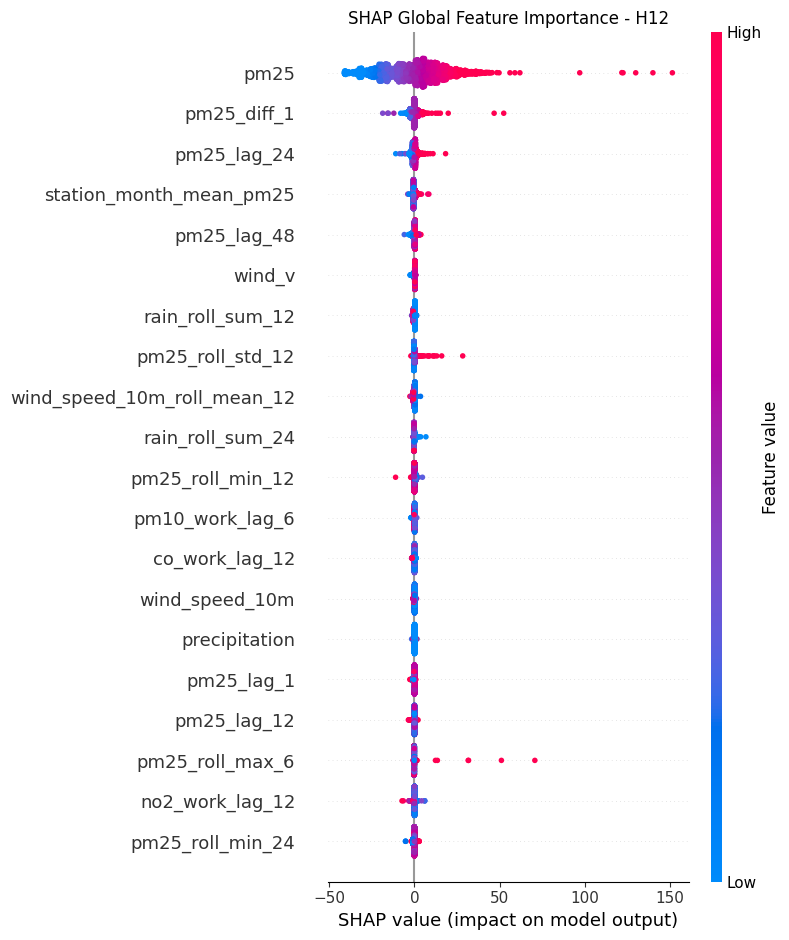


===== SHAP GLOBAL H24 =====


/tmp/ipykernel_276811/413772418.py:25: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Top 10 features:


,feature,mean_abs_shap
1,pm25,8.316684
64,pm25_roll_mean_48,1.699833
141,station_month_mean_pm25,1.315983
44,pm25_lag_1,1.247233
50,pm25_lag_72,1.033341
42,wind_v,0.825483
66,pm25_roll_min_48,0.518690
55,pm25_roll_max_6,0.494154
48,pm25_lag_24,0.428963
63,pm25_roll_max_24,0.284143


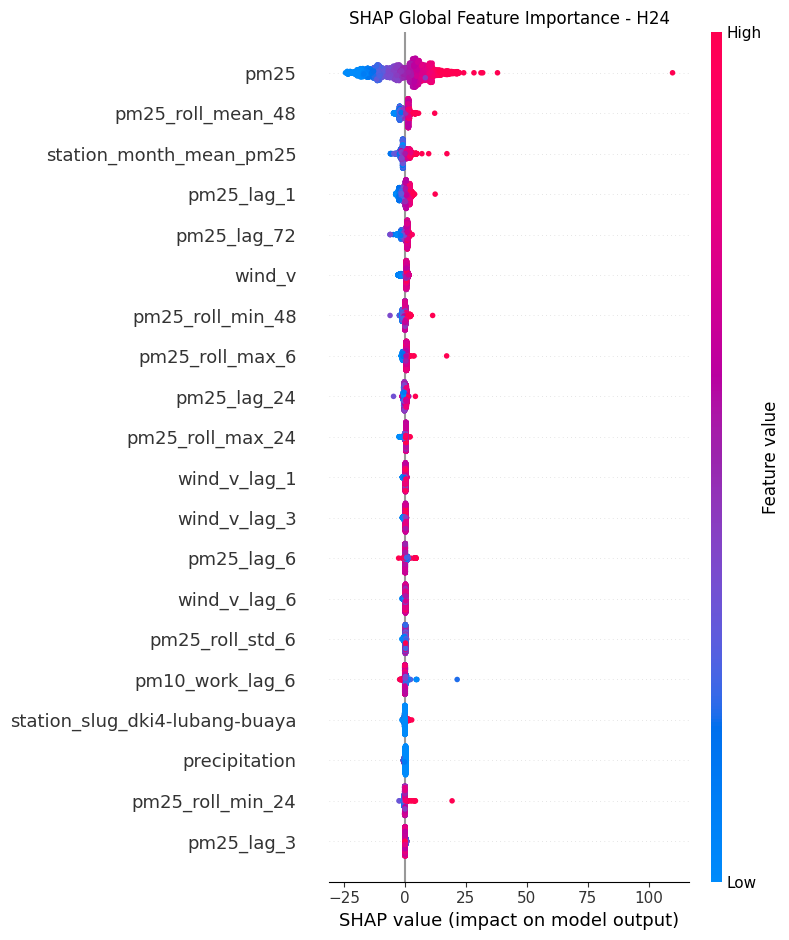

In [2]:
shap_summary_info = []

for horizon, path in DATASET_PATHS.items():
    print(f"\n===== SHAP GLOBAL H{horizon} =====")

    df_h = load_dataset(path)
    target_col = f"target_pm25_t_plus_{horizon}"
    best_params = load_best_lgb_params(horizon)

    X, y = prepare_xy_onehot(df_h, target_col)

    model = LGBMRegressor(
        random_state=SEED,
        verbose=-1,
        **best_params
    )
    model.fit(X, y)

    # ambil sample agar SHAP tidak terlalu berat
    if len(X) > SHAP_SAMPLE_SIZE:
        X_sample = X.sample(SHAP_SAMPLE_SIZE, random_state=SEED)
    else:
        X_sample = X.copy()

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    # ranking global importance
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance_df = pd.DataFrame({
        "feature": X_sample.columns,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False)

    shap_importance_df.to_csv(OUT_DIR / f"shap_importance_h{horizon}.csv", index=False)

    shap_summary_info.append({
        "horizon": horizon,
        "model_rows": len(X),
        "shap_sample_rows": len(X_sample),
        "top_feature": shap_importance_df.iloc[0]["feature"],
        "top_feature_mean_abs_shap": shap_importance_df.iloc[0]["mean_abs_shap"],
    })

    print("Top 10 features:")
    display(shap_importance_df.head(10))

    # summary plot per horizon
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_sample,
        show=False,
        max_display=20
    )
    plt.title(f"SHAP Global Feature Importance - H{horizon}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"shap_global_h{horizon}.png", dpi=200, bbox_inches="tight")
    plt.show()

## Merangkum Informasi SHAP dan Membuat Top-10 Bar Chart

Cell ini mengubah list `shap_summary_info` menjadi DataFrame, lalu menyimpannya ke file:

```text
outputs_shap_ablation/shap_summary_info.csv
```

Ringkasan yang disimpan berisi:

| Kolom | Makna |
|---|---|
| `horizon` | Horizon prediksi |
| `model_rows` | Jumlah baris dataset yang digunakan untuk training model |
| `shap_sample_rows` | Jumlah sample yang dipakai untuk perhitungan SHAP |
| `top_feature` | Fitur paling penting berdasarkan mean absolute SHAP |
| `top_feature_mean_abs_shap` | Nilai mean absolute SHAP dari fitur paling penting |

Output ringkasan menunjukkan:

| Horizon | Model Rows | SHAP Sample Rows | Top Feature | Top Feature Mean Abs SHAP |
|---:|---:|---:|---|---:|
| H6 | 155850 | 3000 | `pm25` | 14.338470 |
| H12 | 155820 | 3000 | `pm25` | 14.039739 |
| H24 | 155760 | 3000 | `pm25` | 8.316684 |

Dari tabel ini terlihat bahwa `pm25` menjadi fitur paling dominan pada semua horizon. Namun, nilai kontribusinya menurun pada H24. Artinya, semakin jauh horizon prediksi, model tidak hanya bergantung pada PM2.5 saat ini, tetapi mulai membutuhkan fitur historis, rolling, dan profil stasiun.

Cell ini juga membuat grafik top-10 SHAP bar chart per horizon:

| Horizon | File Output |
|---:|---|
| H6 | `outputs_shap_ablation/shap_top10_bar_h6.png` |
| H12 | `outputs_shap_ablation/shap_top10_bar_h12.png` |
| H24 | `outputs_shap_ablation/shap_top10_bar_h24.png` |

Grafik bar ini memudahkan pembacaan fitur paling penting karena hanya menampilkan 10 fitur teratas untuk setiap horizon.

Saved: outputs_shap_ablation/shap_summary_info.csv


,horizon,model_rows,shap_sample_rows,top_feature,top_feature_mean_abs_shap
0,6,155850,3000,pm25,14.338470
1,12,155820,3000,pm25,14.032630
2,24,155760,3000,pm25,8.316684


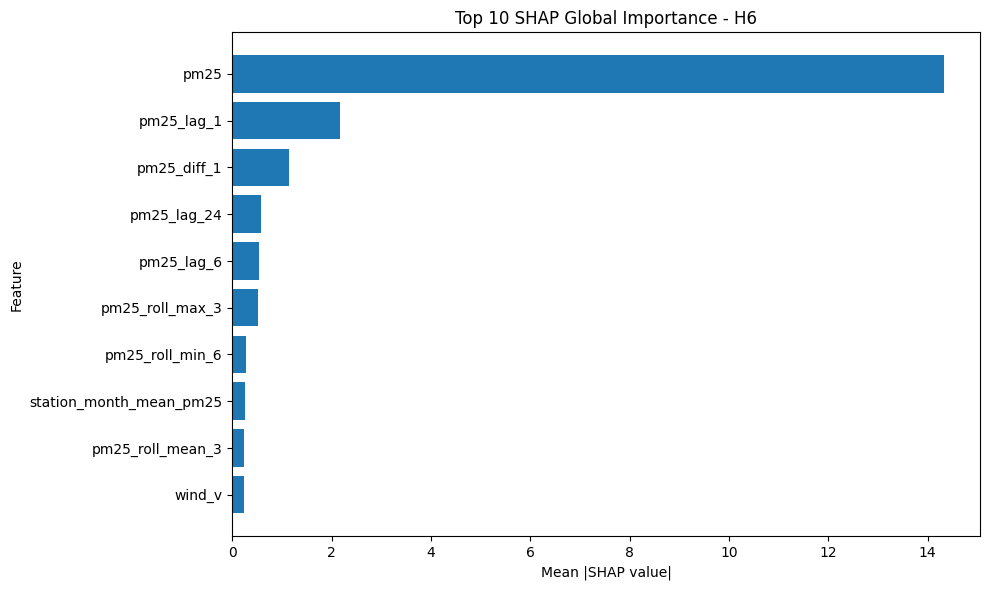

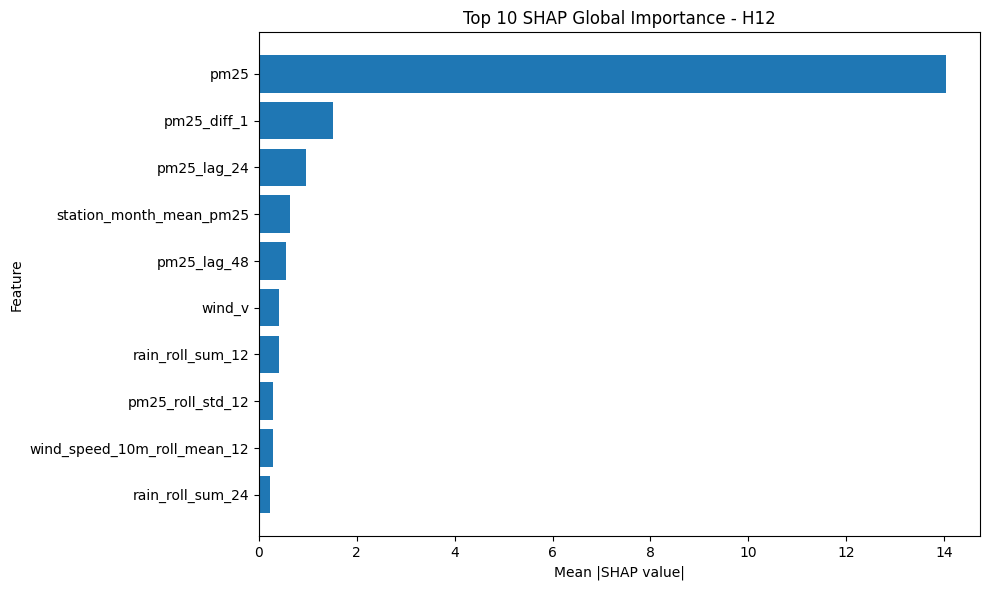

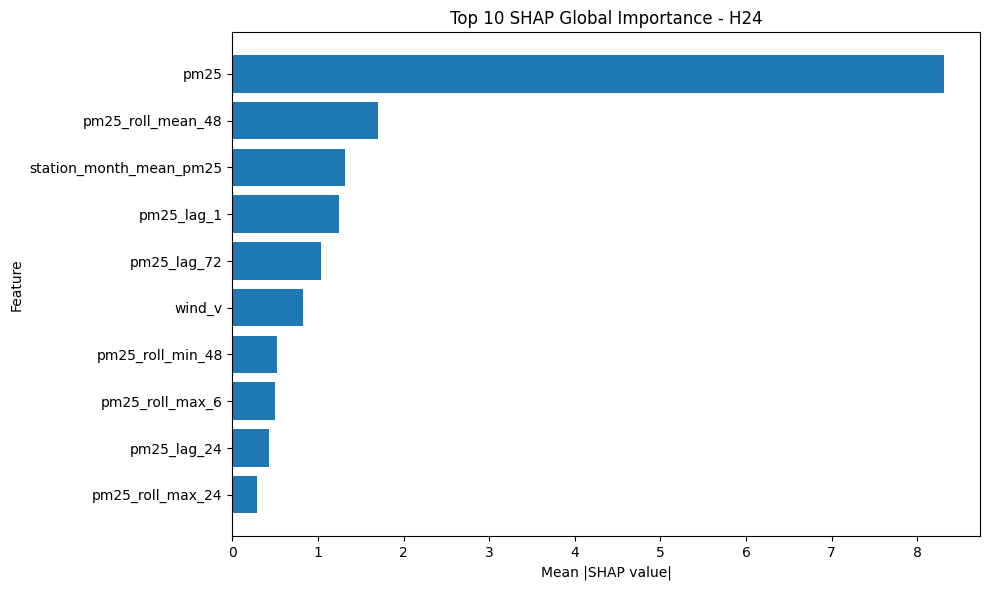

In [3]:
shap_summary_df = pd.DataFrame(shap_summary_info).sort_values("horizon").reset_index(drop=True)
shap_summary_df.to_csv(OUT_DIR / "shap_summary_info.csv", index=False)

print("Saved:", OUT_DIR / "shap_summary_info.csv")
display(shap_summary_df)

# plot top-10 bar chart per horizon
for horizon in [6, 12, 24]:
    fi = pd.read_csv(OUT_DIR / f"shap_importance_h{horizon}.csv").head(10)
    fi = fi.sort_values("mean_abs_shap", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(fi["feature"], fi["mean_abs_shap"])
    plt.xlabel("Mean |SHAP value|")
    plt.ylabel("Feature")
    plt.title(f"Top 10 SHAP Global Importance - H{horizon}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"shap_top10_bar_h{horizon}.png", dpi=200, bbox_inches="tight")
    plt.show()

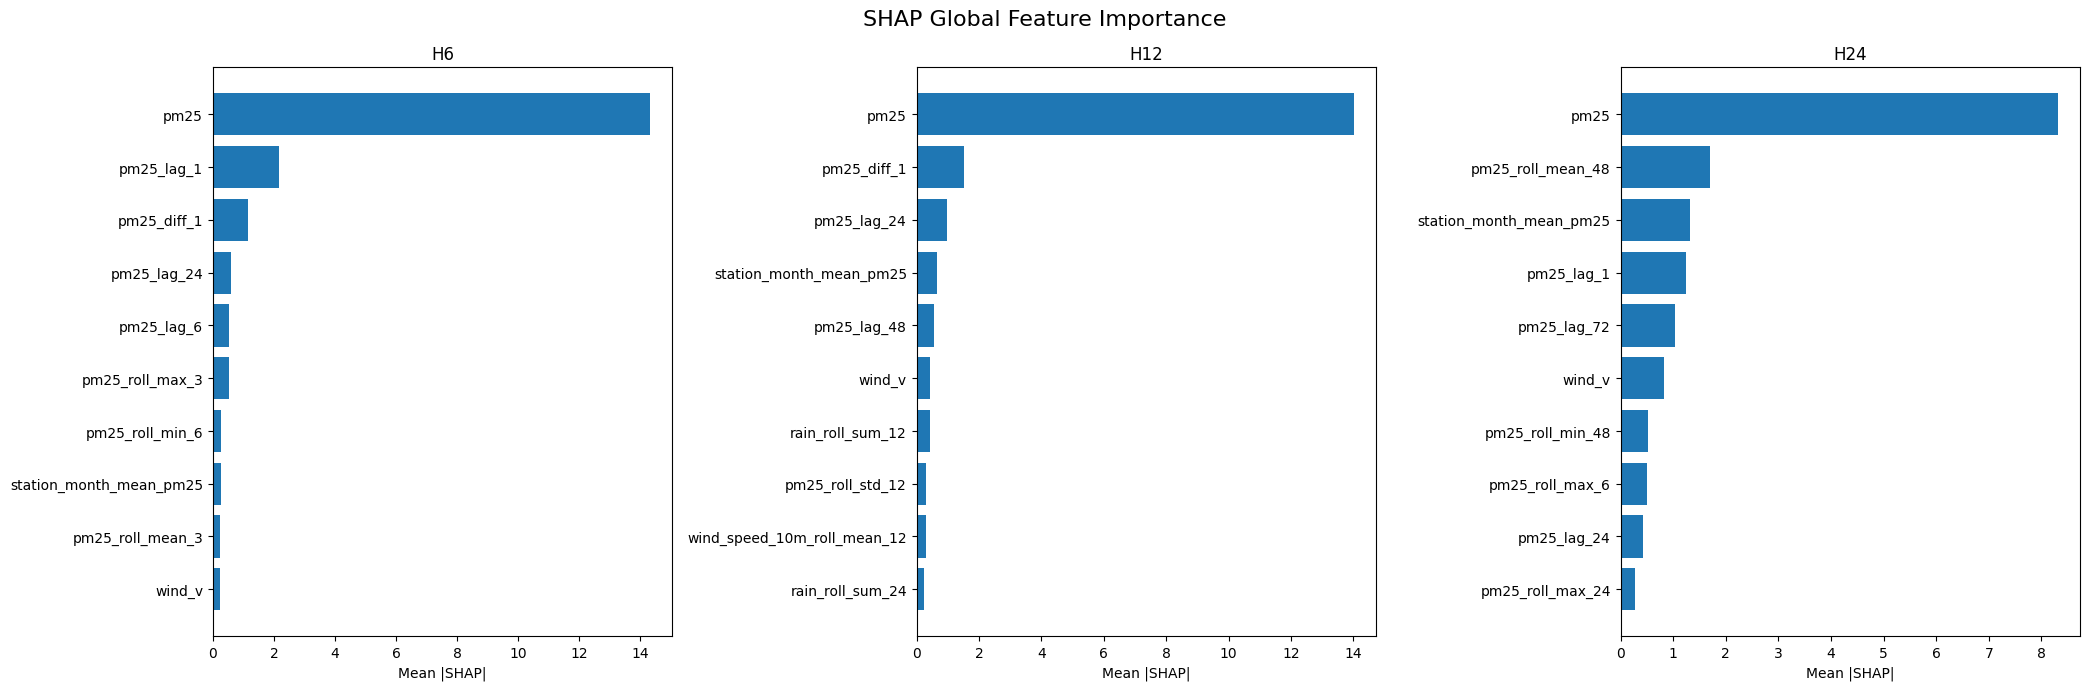

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, horizon in zip(axes, [6, 12, 24]):
    fi = pd.read_csv(OUT_DIR / f"shap_importance_h{horizon}.csv").head(10)
    fi = fi.sort_values("mean_abs_shap", ascending=True)

    ax.barh(fi["feature"], fi["mean_abs_shap"])
    ax.set_title(f"H{horizon}")
    ax.set_xlabel("Mean |SHAP|")

fig.suptitle("SHAP Global Feature Importance", fontsize=16)
plt.tight_layout()
plt.savefig("shap_global.png", dpi=200, bbox_inches="tight")
plt.show()

# Menyusun JSON SHAP untuk Reasoning

Bagian ini membuat output JSON berisi penjelasan SHAP pada level sample.

Berbeda dengan SHAP global importance yang menjelaskan fitur penting secara umum, JSON reasoning ini menjelaskan kontribusi fitur pada sample tertentu.

Setiap horizon menghasilkan 10 sample:

| Jenis Sample | Jumlah |
|---|---:|
| Sample dengan absolute error terbesar | 5 |
| Sample acak dari sisa validation fold terakhir | 5 |

Strategi ini dipakai agar JSON memuat dua jenis kasus:

1. Kasus sulit, yaitu prediksi dengan error paling besar.
2. Kasus pembanding, yaitu sample acak dari periode validation.

Output JSON ini dirancang agar dapat dibaca oleh LLM atau sistem reasoning lanjutan untuk membuat penjelasan yang lebih naratif dan kontekstual.

## Membuat JSON Reasoning untuk H6, H12, dan H24

Cell ini membangun file reasoning JSON untuk setiap horizon prediksi.

Alur proses pada setiap horizon adalah:

1. Membaca dataset hasil ablation.
2. Membaca best params LightGBM.
3. Membentuk 4-fold walk-forward validation.
4. Mengambil fold terakhir sebagai validation window.
5. Melatih LightGBM pada data training fold terakhir.
6. Memprediksi data validation fold terakhir.
7. Menghitung absolute error.
8. Memilih 5 sample dengan error terbesar.
9. Memilih 5 sample acak dari sisa validation.
10. Menghitung SHAP values untuk 10 sample terpilih.
11. Menyusun output JSON sample-level.
12. Menyimpan JSON per horizon dan gabungan semua horizon.

### Konfigurasi Reasoning JSON

| Konfigurasi | Nilai | Fungsi |
|---|---:|---|
| `REASONING_SAMPLE_SIZE` | 10 | Jumlah sample per horizon |
| `TOP_ABS_FEATURES` | 8 | Jumlah fitur SHAP terbesar secara absolut |
| `TOP_POSITIVE_FEATURES` | 4 | Jumlah fitur yang mendorong prediksi naik |
| `TOP_NEGATIVE_FEATURES` | 4 | Jumlah fitur yang mendorong prediksi turun |

### Strategi Pemilihan Sample

Notebook memilih sample dari validation fold terakhir karena fold terakhir merepresentasikan periode data paling baru dalam skema walk-forward validation.

Strategi sample:

| Kelompok | Tujuan |
|---|---|
| 5 absolute error terbesar | Menganalisis kasus prediksi yang paling sulit |
| 5 random sample | Memberikan konteks pembanding yang lebih umum |

### Struktur Isi JSON

Setiap sample JSON berisi:

| Bagian | Isi |
|---|---|
| Metadata | `sample_id`, `datetime`, `target_datetime`, `station_slug`, `station_id` |
| Prediksi | `current_pm25`, `actual_target`, `prediction`, `absolute_error` |
| Context features | Fitur ringkas seperti PM2.5 saat ini, waktu, cuaca, lag, rolling, dan profil stasiun |
| Top absolute contributors | Fitur dengan pengaruh SHAP terbesar |
| Top positive contributors | Fitur yang menaikkan prediksi |
| Top negative contributors | Fitur yang menurunkan prediksi |

### Output yang Dihasilkan

Cell ini menghasilkan file:

```text
outputs_shap_ablation/reasoning_h6.json
outputs_shap_ablation/reasoning_h12.json
outputs_shap_ablation/reasoning_h24.json
outputs_shap_ablation/reasoning_all_horizons.json
```

Output terminal menunjukkan bahwa seluruh file berhasil disimpan.

File `reasoning_all_horizons.json` berisi gabungan reasoning JSON dari H6, H12, dan H24, sehingga lebih praktis jika ingin dipakai sebagai input tunggal untuk proses LLM reasoning.

In [5]:
import json
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
import shap

SEED = 42
REASONING_SAMPLE_SIZE = 10
TOP_ABS_FEATURES = 8
TOP_POSITIVE_FEATURES = 4
TOP_NEGATIVE_FEATURES = 4

# gunakan dataset hasil ablation
DATASET_PATHS = {
    6: "outputs_ablation_datasets/dataset_h6_ablation.csv",
    12: "outputs_ablation_datasets/dataset_h12_ablation.csv",
    24: "outputs_ablation_datasets/dataset_h24_ablation.csv",
}

PHASE2_DIR = Path("outputs_phase2")
OUT_DIR = Path("outputs_shap_ablation")
OUT_DIR.mkdir(exist_ok=True)

def load_dataset(path):
    df = pd.read_csv(path, low_memory=False)
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

    sort_cols = [c for c in ["datetime", "station_slug"] if c in df.columns]
    if sort_cols:
        df = df.sort_values(sort_cols).reset_index(drop=True)
    else:
        df = df.sort_values(["datetime"]).reset_index(drop=True)

    return df

def load_best_lgb_params(horizon):
    fp = PHASE2_DIR / f"best_params_h{horizon}.json"
    if not fp.exists():
        raise FileNotFoundError(f"Best params file tidak ditemukan: {fp}")

    with open(fp, "r") as f:
        obj = json.load(f)

    return obj.get("best_params", {})

def prepare_xy_onehot(df, target_col):
    exclude_cols = {
        target_col,
        "datetime",
        "date",
        "station_name",
        "lokasi",
        "season_simple",
        "pm25_raw",
        "pm25_clean_full",
    }
    exclude_cols = {c for c in exclude_cols if c in df.columns}

    X = df[[c for c in df.columns if c not in exclude_cols]].copy()
    y = df[target_col].copy()

    obj_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    X = pd.get_dummies(X, columns=obj_cols, dummy_na=False)

    return X, y

def make_walk_forward_folds(df, horizon, n_folds=4, valid_ratio_each=0.10):
    df = df.sort_values([c for c in ["datetime", "station_slug"] if c in df.columns]).reset_index(drop=True)
    unique_times = pd.Series(sorted(df["datetime"].dropna().unique()))

    n_times = len(unique_times)
    valid_size = max(1, int(n_times * valid_ratio_each))
    total_valid = n_folds * valid_size

    if total_valid >= n_times:
        raise ValueError("Terlalu banyak fold / valid_ratio terlalu besar.")

    first_valid_start_idx = n_times - total_valid
    folds = []

    for fold_id in range(n_folds):
        valid_start_idx = first_valid_start_idx + fold_id * valid_size
        valid_end_idx = min(valid_start_idx + valid_size - 1, n_times - 1)

        valid_start = pd.Timestamp(unique_times.iloc[valid_start_idx])
        valid_end = pd.Timestamp(unique_times.iloc[valid_end_idx])

        train_end = valid_start - pd.Timedelta(hours=horizon)

        train_mask = df["datetime"] < train_end
        valid_mask = (df["datetime"] >= valid_start) & (df["datetime"] <= valid_end)

        folds.append({
            "fold_id": fold_id + 1,
            "train_idx": df.index[train_mask].to_numpy(),
            "valid_idx": df.index[valid_mask].to_numpy(),
            "train_end": train_end,
            "valid_start": valid_start,
            "valid_end": valid_end,
        })

    return folds

def safe_python_value(v):
    if pd.isna(v):
        return None

    # python bool
    if isinstance(v, bool):
        return bool(v)

    # numpy bool
    if isinstance(v, np.bool_):
        return bool(v)

    # numpy integer
    if isinstance(v, np.integer):
        return int(v)

    # numpy float
    if isinstance(v, np.floating):
        return float(v)

    # timestamp
    if isinstance(v, pd.Timestamp):
        return v.isoformat()

    return v

def sanitize_for_json(obj):
    if isinstance(obj, dict):
        return {str(k): sanitize_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [sanitize_for_json(v) for v in obj]
    else:
        return safe_python_value(obj)

def format_feature_name(feature_name, feature_value):
    # one-hot station slug -> lebih readable
    if feature_name.startswith("station_slug_"):
        slug = feature_name.replace("station_slug_", "")
        return f"station_slug={slug}"

    return feature_name

def build_context_features(row_dict):
    """
    Hanya ambil fitur konteks yang ringkas dan relevan untuk reasoning LLM.
    """
    preferred = [
        "pm25",
        "hour_num", "dayofweek", "month", "is_weekend",
        "is_rush_morning", "is_rush_evening", "is_workhour",
        "season_dry_flag", "has_rain",
        "temperature_2m", "relative_humidity_2m", "rain",
        "surface_pressure", "wind_speed_10m", "wind_u", "wind_v",
        "pm25_lag_1", "pm25_lag_3", "pm25_lag_6", "pm25_lag_12", "pm25_lag_24",
        "pm25_roll_mean_3", "pm25_roll_mean_6", "pm25_roll_mean_12", "pm25_roll_mean_24",
        "station_hour_mean_pm25", "station_month_mean_pm25",
    ]

    context = {}
    for k in preferred:
        if k in row_dict:
            context[k] = safe_python_value(row_dict[k])

    return context

def get_top_shap_contributors(feature_names, feature_values, shap_values_row):
    items = []
    for f, val, sv in zip(feature_names, feature_values, shap_values_row):
        items.append({
            "feature": format_feature_name(f, val),
            "feature_value": safe_python_value(val),
            "shap_value": float(sv),
            "abs_shap_value": float(abs(sv)),
        })

    # top abs
    top_abs = sorted(items, key=lambda x: x["abs_shap_value"], reverse=True)[:TOP_ABS_FEATURES]

    # top positive
    top_pos = [x for x in items if x["shap_value"] > 0]
    top_pos = sorted(top_pos, key=lambda x: x["shap_value"], reverse=True)[:TOP_POSITIVE_FEATURES]

    # top negative
    top_neg = [x for x in items if x["shap_value"] < 0]
    top_neg = sorted(top_neg, key=lambda x: x["shap_value"])[:TOP_NEGATIVE_FEATURES]

    # buang abs_shap_value dari output final biar ringkas
    def strip_abs(lst):
        return [
            {
                "feature": x["feature"],
                "feature_value": x["feature_value"],
                "shap_value": x["shap_value"],
            }
            for x in lst
        ]

    return strip_abs(top_abs), strip_abs(top_pos), strip_abs(top_neg)

reasoning_all = {}

for horizon, path in DATASET_PATHS.items():
    print(f"\n===== BUILD REASONING JSON H{horizon} =====")

    df_h = load_dataset(path)
    target_col = f"target_pm25_t_plus_{horizon}"
    best_params = load_best_lgb_params(horizon)

    folds = make_walk_forward_folds(df_h, horizon=horizon, n_folds=4, valid_ratio_each=0.10)
    last_fold = folds[-1]

    train_df = df_h.iloc[last_fold["train_idx"]].copy()
    valid_df = df_h.iloc[last_fold["valid_idx"]].copy()

    X_train, y_train = prepare_xy_onehot(train_df, target_col)
    X_valid, y_valid = prepare_xy_onehot(valid_df, target_col)

    # samakan kolom valid dengan train
    X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0)

    # reset index supaya sinkron dengan valid_meta
    X_train = X_train.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    X_valid = X_valid.reset_index(drop=True)
    y_valid = y_valid.reset_index(drop=True)

    model = LGBMRegressor(
        random_state=SEED,
        verbose=-1,
        **best_params
    )
    model.fit(X_train, y_train)

    pred_valid = model.predict(X_valid)

    valid_meta = valid_df.copy().reset_index(drop=True)
    valid_meta["prediction"] = pred_valid
    valid_meta["actual_target"] = y_valid
    valid_meta["absolute_error"] = (valid_meta["actual_target"] - valid_meta["prediction"]).abs()
    valid_meta["target_datetime"] = valid_meta["datetime"] + pd.Timedelta(hours=horizon)

    # pilih 10 sample:
    # 5 error terbesar + 5 random dari sisanya
    n_hard = min(5, len(valid_meta))
    hard_idx = valid_meta["absolute_error"].sort_values(ascending=False).head(n_hard).index.tolist()

    remaining_idx = [i for i in valid_meta.index.tolist() if i not in hard_idx]
    n_random = max(0, min(REASONING_SAMPLE_SIZE - n_hard, len(remaining_idx)))

    if n_random > 0:
        rng = np.random.RandomState(SEED + horizon)
        random_idx = rng.choice(remaining_idx, size=n_random, replace=False).tolist()
    else:
        random_idx = []

    selected_idx = hard_idx + random_idx
    selected_idx = selected_idx[:REASONING_SAMPLE_SIZE]

    selected_meta = valid_meta.iloc[selected_idx].copy().reset_index(drop=True)
    selected_X = X_valid.iloc[selected_idx].copy().reset_index(drop=True)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(selected_X)

    samples_json = []

    for i in range(len(selected_meta)):
        row_meta = selected_meta.iloc[i].to_dict()
        row_x = selected_X.iloc[i]
        row_shap = shap_values[i]

        top_abs, top_pos, top_neg = get_top_shap_contributors(
            feature_names=selected_X.columns.tolist(),
            feature_values=row_x.values.tolist(),
            shap_values_row=row_shap
        )

        sample_json = {
            "sample_id": i + 1,
            "datetime": safe_python_value(row_meta.get("datetime")),
            "target_datetime": safe_python_value(row_meta.get("target_datetime")),
            "station_slug": safe_python_value(row_meta.get("station_slug")) if "station_slug" in selected_meta.columns else None,
            "station_id": safe_python_value(row_meta.get("station_id")) if "station_id" in selected_meta.columns else None,
            "current_pm25": safe_python_value(row_meta.get("pm25")) if "pm25" in selected_meta.columns else None,
            "actual_target": safe_python_value(row_meta.get("actual_target")),
            "prediction": safe_python_value(row_meta.get("prediction")),
            "absolute_error": safe_python_value(row_meta.get("absolute_error")),
            "context_features": build_context_features(row_meta),
            "top_absolute_contributors": top_abs,
            "top_positive_contributors": top_pos,
            "top_negative_contributors": top_neg,
        }
        samples_json.append(sample_json)

    reasoning_obj = {
        "horizon": horizon,
        "target_column": target_col,
        "selection_strategy": "5 highest absolute error samples + 5 random remaining samples from last walk-forward validation fold",
        "validation_window": {
            "fold_id": int(last_fold["fold_id"]),
            "valid_start": safe_python_value(last_fold["valid_start"]),
            "valid_end": safe_python_value(last_fold["valid_end"]),
            "train_end": safe_python_value(last_fold["train_end"]),
        },
        "n_validation_rows": int(len(valid_meta)),
        "n_reasoning_samples": int(len(samples_json)),
        "samples": samples_json,
    }

    out_path = OUT_DIR / f"reasoning_h{horizon}.json"
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(sanitize_for_json(reasoning_obj), f, ensure_ascii=False, indent=2)

    reasoning_all[f"h{horizon}"] = reasoning_obj

    print(f"Saved: {out_path}")

# gabungan semua horizon
all_path = OUT_DIR / "reasoning_all_horizons.json"
with open(all_path, "w", encoding="utf-8") as f:
    json.dump(sanitize_for_json(reasoning_all), f, ensure_ascii=False, indent=2)

print(f"\nSaved combined: {all_path}")


===== BUILD REASONING JSON H6 =====
Saved: outputs_shap_ablation/reasoning_h6.json

===== BUILD REASONING JSON H12 =====
Saved: outputs_shap_ablation/reasoning_h12.json

===== BUILD REASONING JSON H24 =====
Saved: outputs_shap_ablation/reasoning_h24.json

Saved combined: outputs_shap_ablation/reasoning_all_horizons.json


# Struktur Folder dan File Output Notebook

Notebook ini menggunakan input dari dataset hasil ablation dan best params LightGBM.

Input utama notebook adalah:

```text
outputs_ablation_datasets/dataset_h6_ablation.csv
outputs_ablation_datasets/dataset_h12_ablation.csv
outputs_ablation_datasets/dataset_h24_ablation.csv
```

Notebook juga membaca best params dari folder:

```text
outputs_phase2/
```

Folder output utama notebook ini adalah:

```text
outputs_shap_ablation/
```

Struktur output notebook dapat diringkas sebagai berikut:

```text
project/
│
├── outputs_ablation_datasets/
│   ├── dataset_h6_ablation.csv
│   ├── dataset_h12_ablation.csv
│   └── dataset_h24_ablation.csv
│
├── outputs_phase2/
│   ├── best_params_h6.json
│   ├── best_params_h12.json
│   └── best_params_h24.json
│
├── outputs_shap_ablation/
│   ├── shap_importance_h6.csv
│   ├── shap_importance_h12.csv
│   ├── shap_importance_h24.csv
│   │
│   ├── shap_global_h6.png
│   ├── shap_global_h12.png
│   ├── shap_global_h24.png
│   │
│   ├── shap_top10_bar_h6.png
│   ├── shap_top10_bar_h12.png
│   ├── shap_top10_bar_h24.png
│   │
│   ├── shap_summary_info.csv
│   │
│   ├── reasoning_h6.json
│   ├── reasoning_h12.json
│   ├── reasoning_h24.json
│   └── reasoning_all_horizons.json
│
└── shap_global.png
```

### Penjelasan File Output SHAP

| File | Fungsi |
|---|---|
| `shap_importance_h6.csv` | Ranking SHAP global importance untuk horizon 6 jam |
| `shap_importance_h12.csv` | Ranking SHAP global importance untuk horizon 12 jam |
| `shap_importance_h24.csv` | Ranking SHAP global importance untuk horizon 24 jam |
| `shap_global_h6.png` | Summary plot SHAP untuk H6 |
| `shap_global_h12.png` | Summary plot SHAP untuk H12 |
| `shap_global_h24.png` | Summary plot SHAP untuk H24 |
| `shap_top10_bar_h6.png` | Bar chart top-10 SHAP features H6 |
| `shap_top10_bar_h12.png` | Bar chart top-10 SHAP features H12 |
| `shap_top10_bar_h24.png` | Bar chart top-10 SHAP features H24 |
| `shap_summary_info.csv` | Ringkasan jumlah baris, sample SHAP, dan top feature per horizon |
| `shap_global.png` | Grafik gabungan top-10 SHAP H6, H12, dan H24 |

### Penjelasan File Output Reasoning JSON

| File | Fungsi |
|---|---|
| `reasoning_h6.json` | Sample-level SHAP explanation untuk H6 |
| `reasoning_h12.json` | Sample-level SHAP explanation untuk H12 |
| `reasoning_h24.json` | Sample-level SHAP explanation untuk H24 |
| `reasoning_all_horizons.json` | Gabungan reasoning JSON untuk semua horizon |

### Ringkasan Hasil SHAP Global

| Horizon | Top Feature | Mean Absolute SHAP |
|---:|---|---:|
| H6 | `pm25` | 14.338470 |
| H12 | `pm25` | 14.039739 |
| H24 | `pm25` | 8.316684 |

Secara keseluruhan, notebook ini menunjukkan bahwa `pm25` saat ini tetap menjadi fitur paling penting untuk semua horizon. Namun, semakin panjang horizon prediksi, fitur historis seperti lag panjang, rolling PM2.5, dan profil historis stasiun mulai menjadi semakin penting.

Output terpenting dari notebook ini adalah:

```text
outputs_shap_ablation/shap_summary_info.csv
outputs_shap_ablation/shap_importance_h6.csv
outputs_shap_ablation/shap_importance_h12.csv
outputs_shap_ablation/shap_importance_h24.csv
outputs_shap_ablation/reasoning_all_horizons.json
```

File-file tersebut dapat digunakan untuk interpretasi model, pelaporan hasil XAI, analisis sample error, dan penyusunan reasoning berbasis LLM.